In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")
sns.set(font_scale=1.1)


In [2]:
df = pd.DataFrame({'h':[150,160,170,185,190],
                   'w':[50,58,70,80,90]})
df

,h,w
0,150,50
1,160,58
2,170,70
3,185,80
4,190,90


In [6]:
m = df.mean()
s = df.std()
z = (df-m)/s
z.round(2)

,h,w
0,-1.25,-1.21
1,-0.66,-0.72
2,-0.06,0.02
3,0.84,0.64
4,1.14,1.26


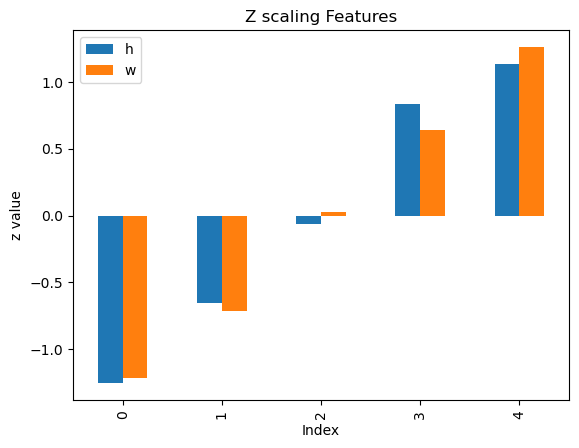

In [10]:
z.plot(kind="bar")
plt.title("Z scaling Features")
plt.xlabel("Index") 
plt.ylabel('z value')
plt.show()

Min–Max Scaling (Rescaling to [0,1])

In [11]:
df = pd.DataFrame({'h':[150,175,170,180,190],
                   'w':[50,60,70,180,90]})
df

,h,w
0,150,50
1,175,60
2,170,70
3,180,180
4,190,90


In [12]:
mn = df.min()
mx = df.max()
rg = mx-mn
mm = (df-mn)/rg
mm.round(2)

,h,w
0,0.00,0.00
1,0.62,0.08
2,0.50,0.15
3,0.75,1.00
4,1.00,0.31


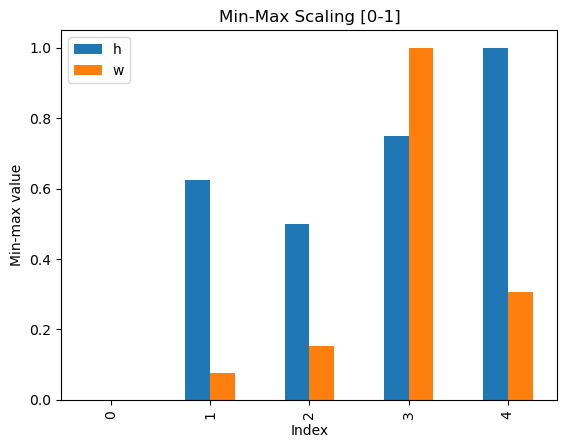

In [13]:
#Plot
mm.plot(kind='bar')
plt.title("Min-Max Scaling [0-1]")
plt.xlabel("Index"); plt.ylabel('Min-max value')
plt.show()

##Robust Scaling (Outlier-Resistant)

In [15]:
df = pd.DataFrame({'h':[150,160,170,180,300],
                   'w':[50,60,70,80,200]})
df

,h,w
0,150,50
1,160,60
2,170,70
3,180,80
4,300,200


In [16]:
md = df.median()
q1 = df.quantile(.25)
q3 = df.quantile(.75)
iqr = q3-q1

rb = (df-md)/iqr
rb

,h,w
0,-1.0,-1.0
1,-0.5,-0.5
2,0.0,0.0
3,0.5,0.5
4,6.5,6.5


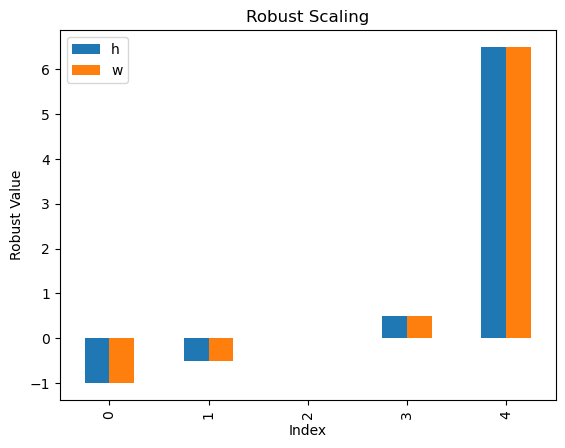

In [17]:
rb.plot(kind="bar")
plt.title("Robust Scaling")
plt.xlabel("Index")
plt.ylabel("Robust Value")
plt.show()

In [18]:
# standardization/z score
m = df.mean()
s = df.std()
z = (df-m)/s

# min max
mn = df.mean()
mx = df.max()
mm = (df-mn)/mx-mn

# side by side
out = pd.concat([
    df,
    z.add_prefix('z_'),
    mm.add_prefix('mm_'),
    rb.add_prefix('rb_')
],axis=1)

out.round(2)

,h,w,z_h,z_w,mm_h,mm_w,rb_h,rb_w
0,150,50,-0.68,-0.68,-192.14,-92.21,-1.0,-1.0
1,160,60,-0.52,-0.52,-192.11,-92.16,-0.5,-0.5
2,170,70,-0.36,-0.36,-192.07,-92.11,0.0,0.0
3,180,80,-0.20,-0.20,-192.04,-92.06,0.5,0.5
4,300,200,1.76,1.76,-191.64,-91.46,6.5,6.5


one hot encoding

df = pd.DataFrame({
    "id":[1,2,3,4],
    "color":["red","blue","green","red"],
    "size":["Small","Medium","Large","Medium"],
    "price":[10,12,15,11]
})

df

In [23]:
# Step 2: Apply one-hot encoding to the 'color' column
d_color = pd.get_dummies(df["color"],prefix="color",dtype=int)

In [24]:
# Step 3: Combine the new columns back with the original data
df_encoded = pd.concat([df,d_color],axis=1)

In [25]:
# Step 4: Drop the old 'color' column if you no longer need it
df_encoded = df_encoded.drop("color",axis=1)
df_encoded

,id,size,price,color_blue,color_green,color_red
0,1,Small,10,0,0,1
1,2,Medium,12,1,0,0
2,3,Large,15,0,1,0
3,4,Medium,11,0,0,1


Ordinal Encoding (for ordered categories)

In [28]:
df = pd.DataFrame({
    "id":[1,2,3,4],
    "color":["red","blue","green","red"],
    "size":["Small","Medium","Large","Medium"],
    "price":[10,12,15,11]
})
df

,id,color,size,price
0,1,red,Small,10
1,2,blue,Medium,12
2,3,green,Large,15
3,4,red,Medium,11


In [30]:
# Step 2: declare the ordinal order
order = {"Small":1, "Medium":2, "Large":3}

In [31]:
# Step 3: convert the whole feature
# df["size_encoded"]=df["size"].map(order).astype(int)
df["size"] = df["size"].map(order).astype(int) 

In [32]:
df

,id,color,size,price
0,1,red,1,10
1,2,blue,2,12
2,3,green,3,15
3,4,red,2,11


In [38]:
df = pd.read_csv("heart.csv")
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [39]:
# Basic info about rows, columns, and data types
print("Shape: ", df.shape)

Shape:  (918, 12)


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [42]:
# Quick descriptive statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [46]:
target_col = "HeartDisease"
numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

print("Target:", target_col)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Target: HeartDisease
Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


# Module 06: Exploratory Data Analysis (EDA)

## 3. Missing Values and Basic Quality Checks

In [47]:
# Check missing values count per column
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

> Insight: Even if the dataset description claims there are no missing values, always verify. Real world data often breaks promises.

In [50]:
# Look at some basic value ranges
df[numeric_cols].agg(["min", "max", "mean", "median"]).T

,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


In [51]:
for c in categorical_col:
    print(c, df[c].unique())
    

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


> Insight: Look for impossible or suspicious ranges such as zero cholesterol or resting blood pressure that is extremely low or high. These may be data entry issues or special codes that you need to treat carefully.

## 4. Understanding Distributions with Histograms and Boxplots

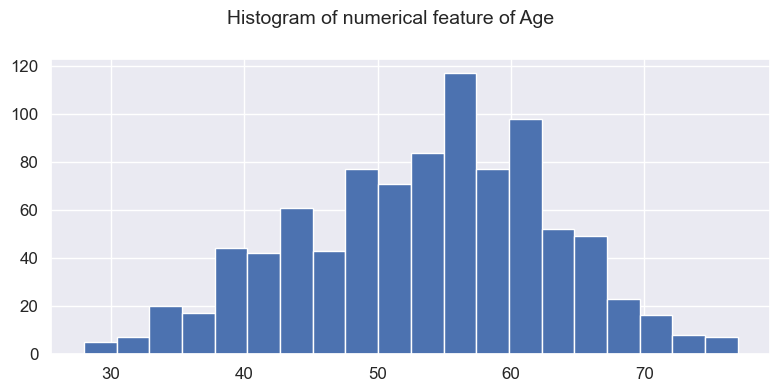

In [56]:
# Histograms for numeric features
df["Age"].hist(bins=20, figsize=(8,4))
plt.suptitle("Histogram of numerical feature of Age", fontsize=14)
plt.tight_layout()
plt.show()

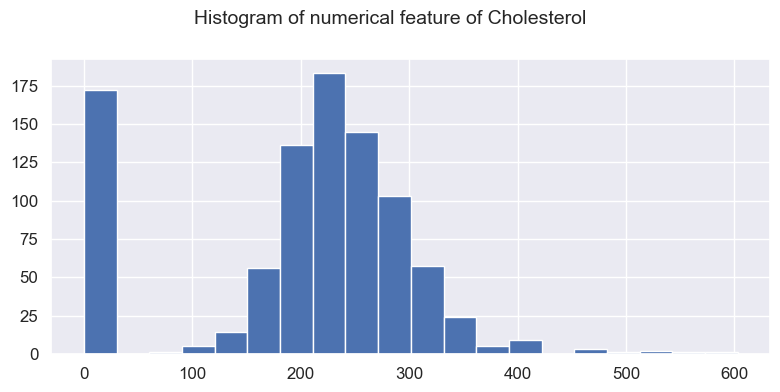

In [57]:
df["Cholesterol"].hist(bins=20, figsize=(8,4))
plt.suptitle("Histogram of numerical feature of Cholesterol", fontsize=14)
plt.tight_layout()
plt.show()

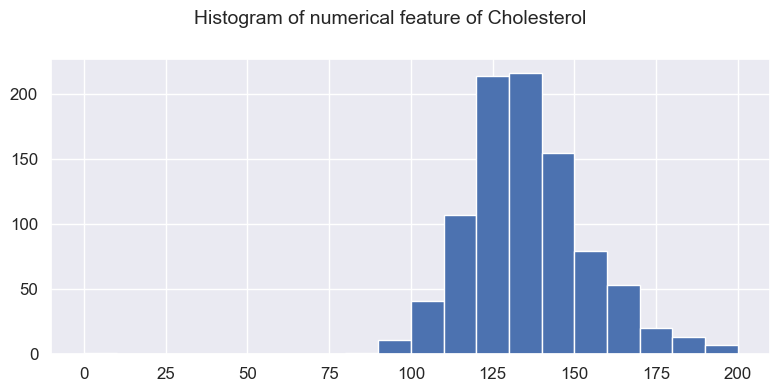

In [58]:
df["RestingBP"].hist(bins=20, figsize=(8,4))
plt.suptitle("Histogram of numerical feature of RestingBP", fontsize=14)
plt.tight_layout()
plt.show()

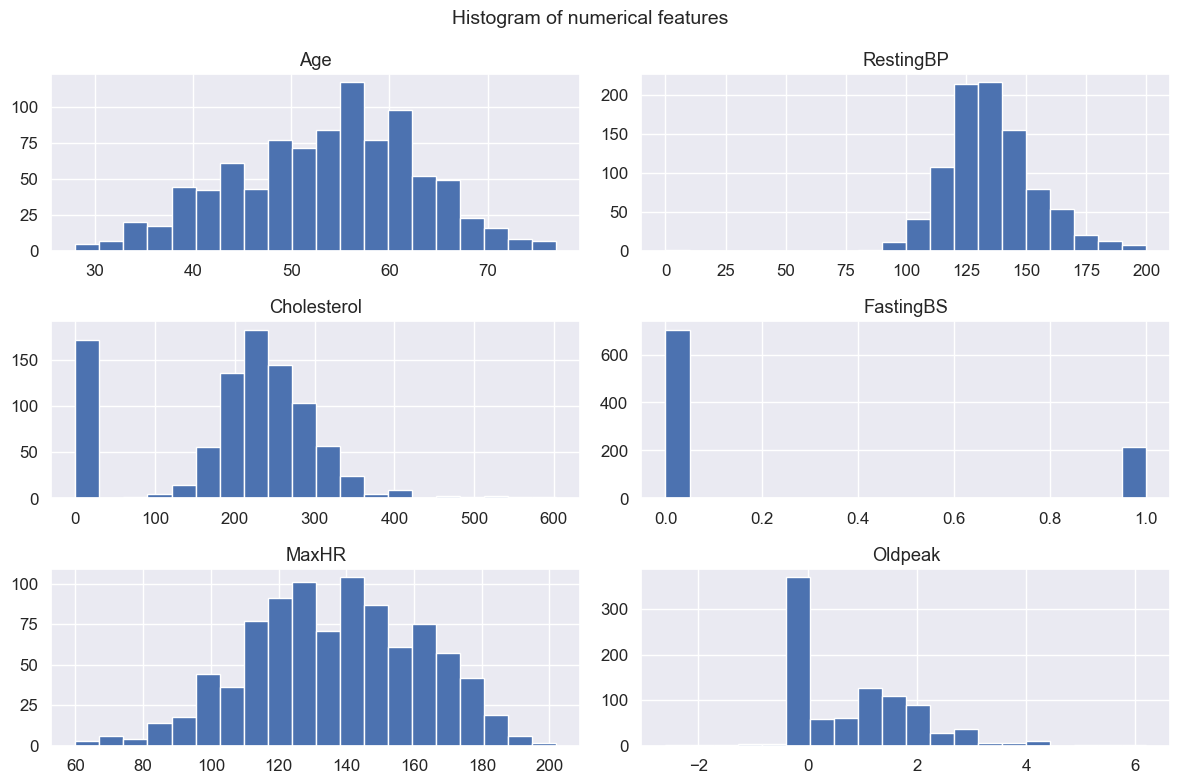

In [62]:
df[numeric_col].hist(bins=20, figsize=(12,8))
plt.suptitle("Histogram of numerical features", fontsize=14)
plt.tight_layout()
plt.show()

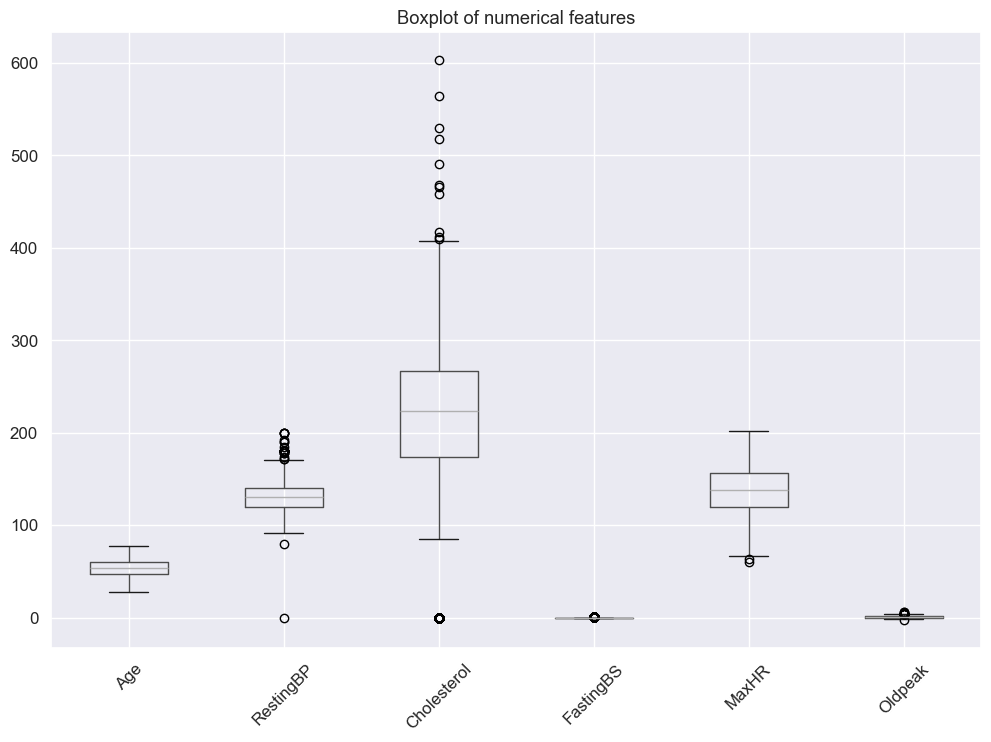

In [65]:
# Boxplots to get a sense of spread and possible outliers
plt.figure(figsize=(12,8))
df[numeric_col].boxplot()
plt.title("Boxplot of numerical features")
plt.xticks(rotation=45)
plt.show()

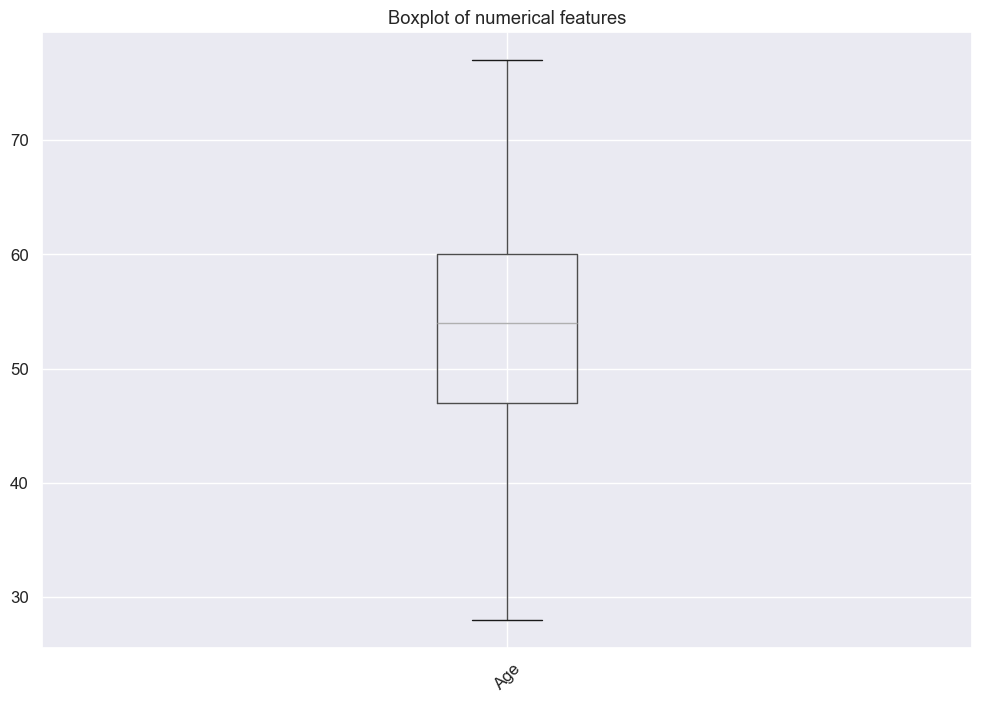

In [66]:
plt.figure(figsize=(12,8))
df.boxplot(column=numeric_col[0])
plt.title("Boxplot of numerical features")
plt.xticks(rotation=45)
plt.show()

> Insight: Histograms tell you the shape of distributions. Boxplots give a quick view of spread and potential outliers. Before you do any scaling or transformation, you should already have a mental picture of how these variables behave.

## 5. Target Distribution and Class Imbalance

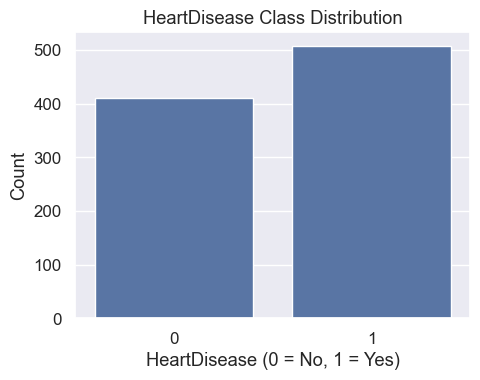

In [68]:
#Target Distribution and Class Imbalance
plt.figure(figsize=(5,4))
sns.countplot(x=df[target_col])
plt.title("HeartDisease Class Distribution")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [69]:
df[target_col].value_counts(normalize=True)

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

> Insight: If one class dominates heavily, you may need resampling strategies or class weighted models later. Even if the imbalance is moderate, it is critical to be aware of it before you start modeling.

## 6. Categorical Feature Exploration

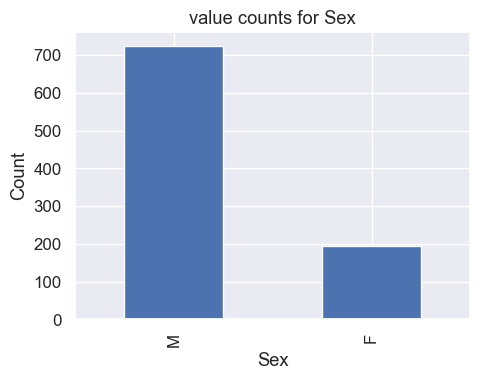

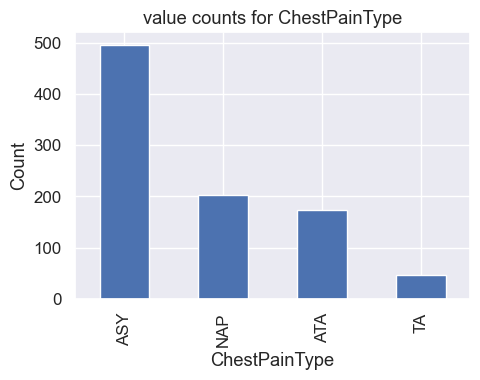

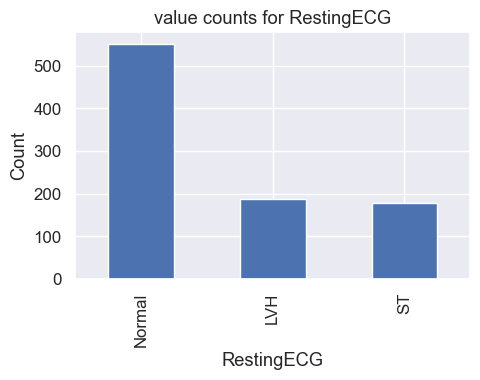

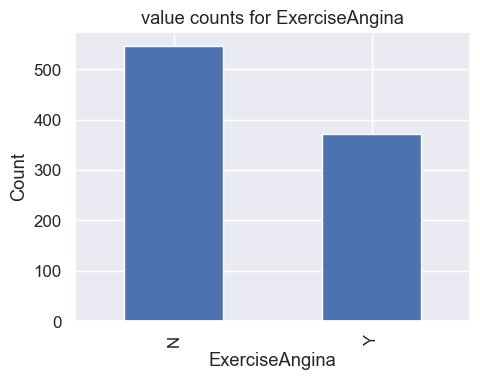

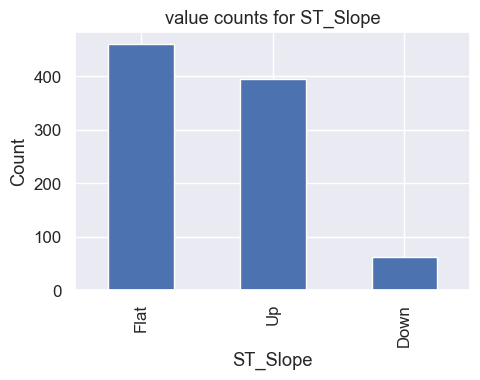

In [70]:
# categorical feature Exploration
for c in categorical_col:
    plt.figure(figsize=(5,4))
    df[c].value_counts().plot(kind="bar")
    plt.title(f"value counts for {c}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 7. Relationships Between Features and Target

We will first visualize numeric features against the target and then look at correlations.

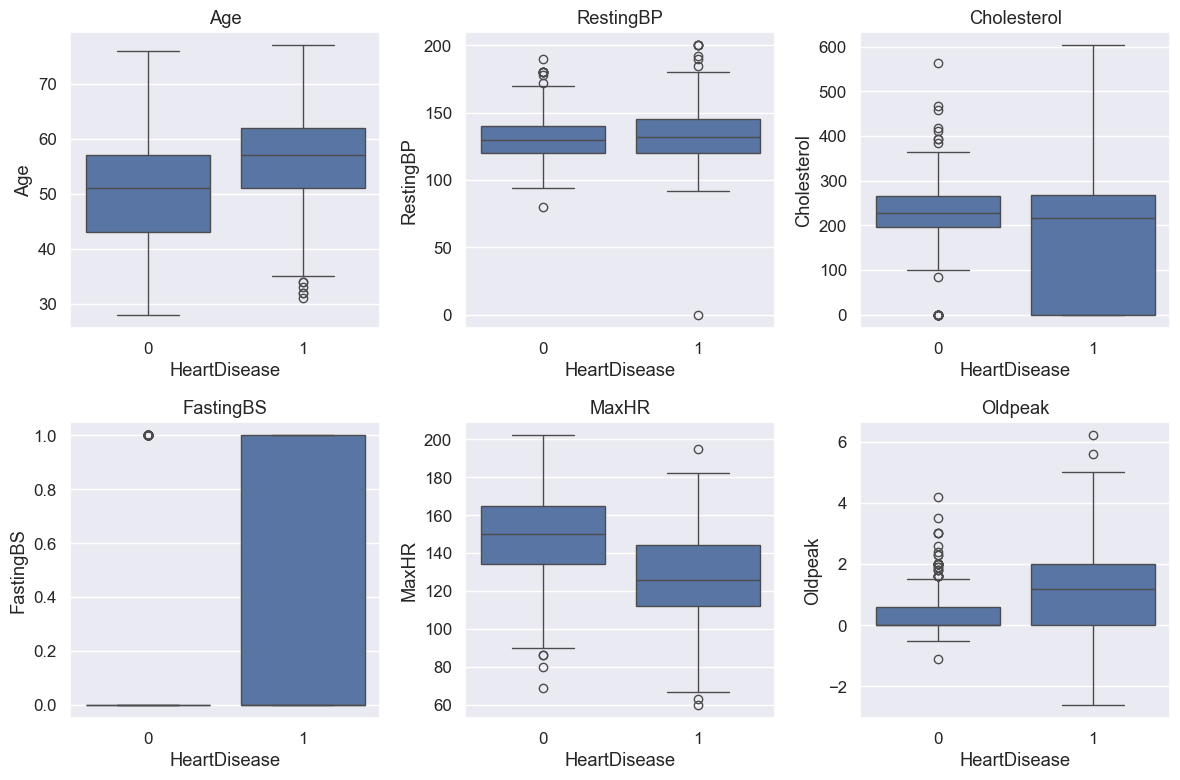

In [71]:
# Boxplots of numeric features split by HeartDisease
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_col,1):
    plt.subplot(2,3,i)
    sns.boxplot(x=df[target_col], y = df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

> Insight: Large differences in distributions between target classes often signal strong predictive potential. If the distributions are almost identical, that feature may be less useful on its own.

### 7.1 Pairplot for a Subset of Features

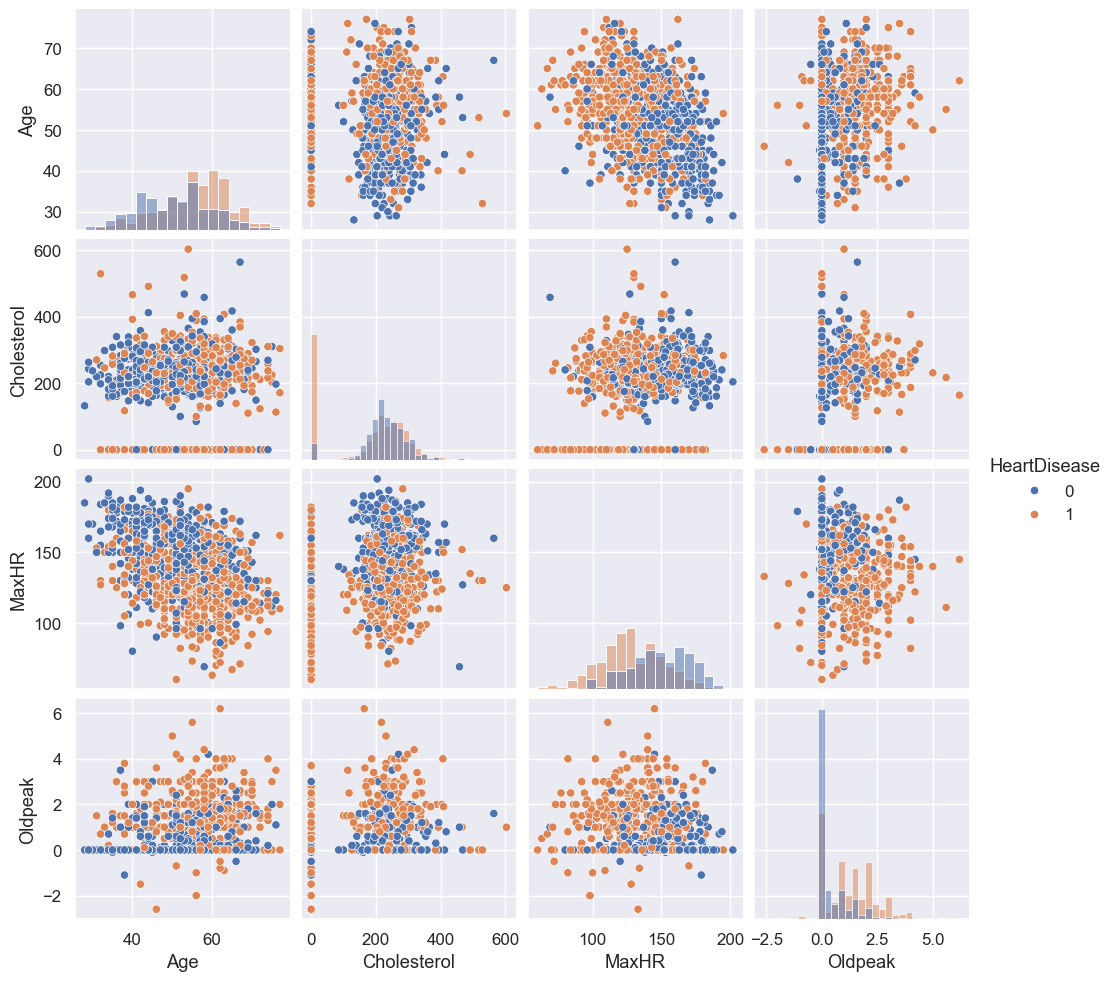

In [72]:
sns.pairplot(df[["Age", "Cholesterol", "MaxHR", "Oldpeak", "HeartDisease"]], hue="HeartDisease", diag_kind="hist")
plt.show()

> Insight: Pairplots are expensive but powerful for small to medium sized datasets. Use them on a subset of features that you suspect are important, not on every column.

### 7.2 Correlation Matrix and Heatmap

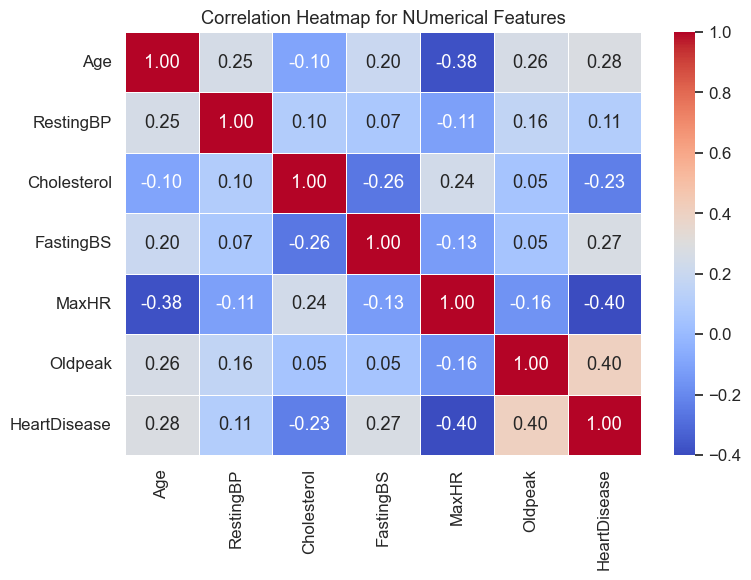

In [73]:
corr_matrix = df[numeric_col + [target_col]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for NUmerical Features")
plt.tight_layout()
plt.show()

In [74]:
corr_matrix[target_col].sort_values(ascending=False)

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64

> Insight: High absolute correlation with the target is interesting, but do not ignore low correlation features. Some of them can become powerful in combination with others. Also watch for high correlation between predictors, which may indicate redundancy.

### 7.3 Categorical Features vs Target


Proportion of HeartDisease within Sex


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


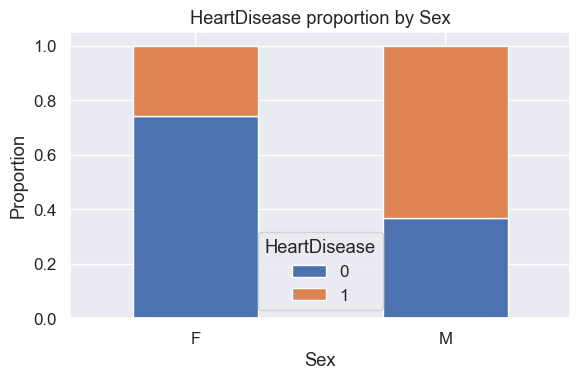


Proportion of HeartDisease within ChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


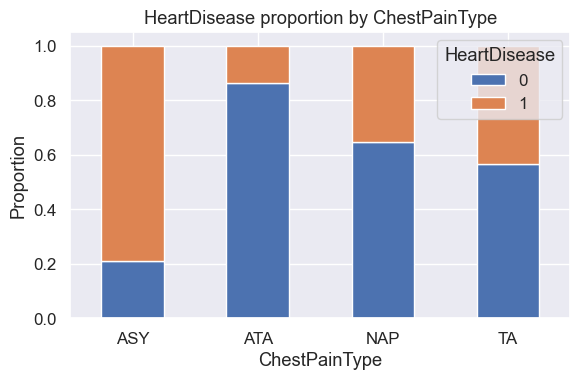


Proportion of HeartDisease within RestingECG


HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


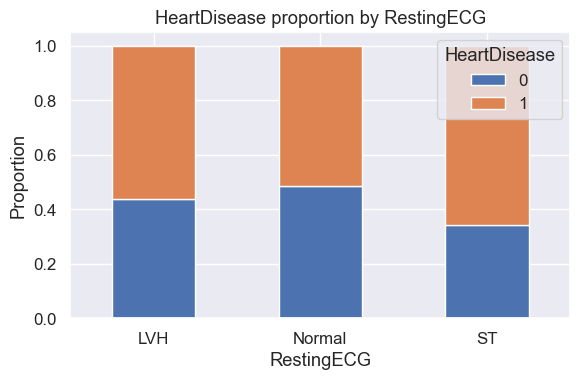


Proportion of HeartDisease within ExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


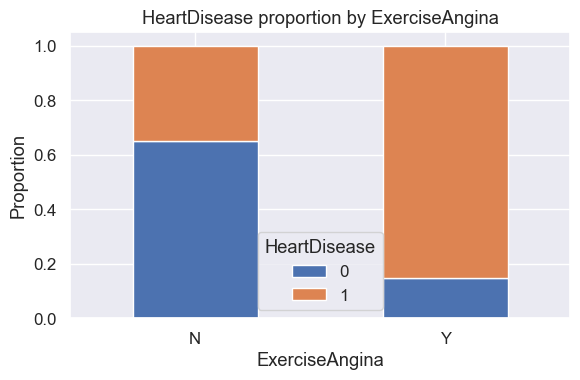


Proportion of HeartDisease within ST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


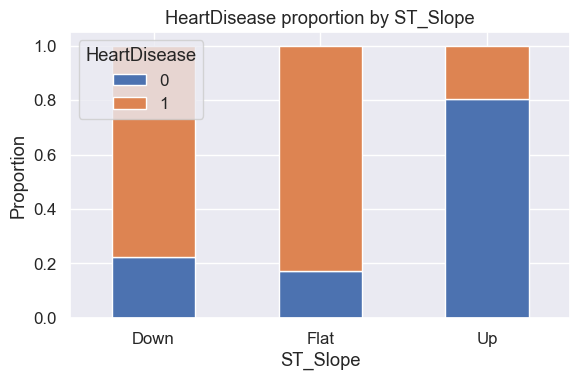

In [77]:
#Categorical Features vs Target
for c in categorical_col:
    ct = pd.crosstab(df[c], df[target_col], normalize="index")
    print(f"\nProportion of HeartDisease within {c}")
    display(ct)

    ct.plot(kind="bar", stacked=True, figsize=(6,4))
    plt.title(f"HeartDisease proportion by {c}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()